In [ ]:
import os
import requests

In [ ]:
DATA_DIR = "data"
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
URLS = {
    'KDDTrain+.txt':'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt',
    'KDDTest+.txt' : 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt'
}

def download_file(url,filename):
    local_path = os.path.join(DATA_DIR, filename)

    if os.path.exists(local_path):
        print(f"Correct file found: {filename} already exists")
        return
    print(f"Downloading {filename}...")
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(local_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size = 8000):
                f.write(chunk)
        print(f"Success saved to {local_path}")
    except Exception as e:
        print(f"Failed to download {filename} :{e}")

In [ ]:
for filename, url in URLS.items():
    download_file(url,filename)
print("\nAll files should now be in 'data' folder.")

Success saved to data/KDDTrain+.txt
Success saved to data/KDDTest+.txt

All files should now be in 'data' folder.


In [ ]:
# Step:0 import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
import pandas as pd

#Step1:Load Provide Dataset, Column names from NSL-KDD (full list)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack_type','level'
]

train_path = os.path.join(DATA_DIR, 'KDDTrain+.txt')
test_path = os.path.join(DATA_DIR, 'KDDTest+.txt')

# Read CSV with our column names
train_df = pd.read_csv(train_path, names=columns)
test_df = pd.read_csv(test_path, names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
#Step 2:Slice Data(TCP Traffic,Normal/DOS) before tht we will check what are the unique attack types in the training data
attack_counts=train_df['attack_type'].value_counts()
print("Attack type counts:\n",attack_counts)

Attack type counts:
 attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [ ]:
#to make it easier of ML,we can create a new column attack_category
def categorize_attack(x):
    if x=='normal':
        return 'normal'
    elif x in['neptune','smurf','back','teardrop','pod','land']:
        return 'dos'
    elif x in ['satan','ipsweep','portsweep','nmap']:
        return 'probe' #scanning attacks
    elif x in ['guess_passwd','ftp_write','warezclient','warezmaster','phf','multihop','imap','spy','perl']:
        return 'r2l'  #Remote to Local
    elif x in ['buffer_overflow','loadmodule','rootkit']:
        return 'u2r' #User to Root
    else:
        return 'other'

train_df['attack_category'] = train_df['attack_type'].apply(categorize_attack)
test_df['attack_category'] = test_df['attack_type'].apply(categorize_attack)
print(train_df['attack_category'].value_counts())

attack_category
normal    67343
dos       45927
probe     11656
r2l         998
u2r          49
Name: count, dtype: int64


Protocol vs Attack Category:
 attack_category    dos  normal  probe  r2l  u2r
protocol_type                                  
icmp              2847    1309   4135    0    0
tcp              42188   53600   5857  998   46
udp                892   12434   1664    0    3


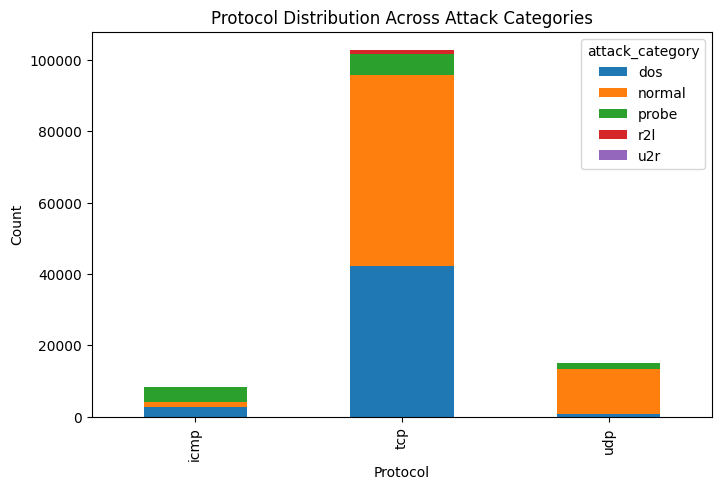

In [ ]:
# ===============================
# My Exploration — Protocol vs Attack Category
# ===============================

proto_attack = pd.crosstab(train_df['protocol_type'], train_df['attack_category'])

print("Protocol vs Attack Category:\n", proto_attack)

proto_attack.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Protocol Distribution Across Attack Categories")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

In [ ]:
# Step 3: Keep only TCP traffic
tcp_train = train_df[train_df['protocol_type'] == 'tcp']
tcp_test = test_df[test_df['protocol_type'] == 'tcp']

# Step 4: Binary classification: normal vs DOS attacks
binary_train = tcp_train[tcp_train['attack_category'].isin(['normal','dos'])]
binary_test = tcp_test[tcp_test['attack_category'].isin(['normal','dos'])]

# Quick check
print("Binary Train shape:", binary_train.shape)
print(binary_train['attack_category'].value_counts())

print("Binary Test shape:", binary_test.shape)
print(binary_test['attack_category'].value_counts())


Binary Train shape: (95788, 44)
attack_category
normal    53600
dos       42188
Name: count, dtype: int64
Binary Test shape: (12865, 44)
attack_category
normal    7842
dos       5023
Name: count, dtype: int64


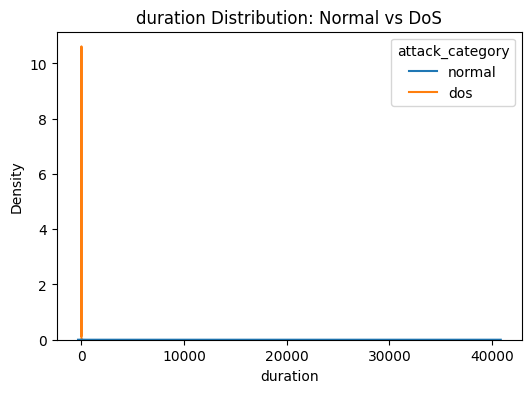

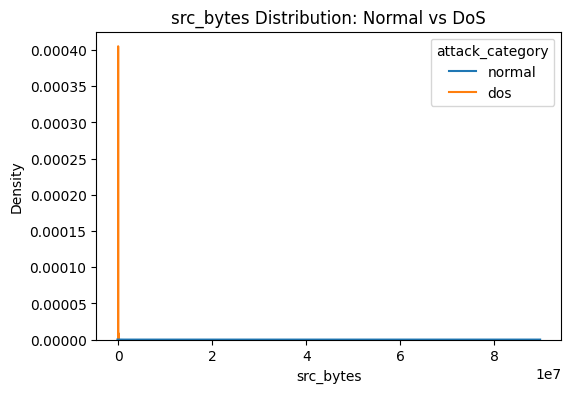

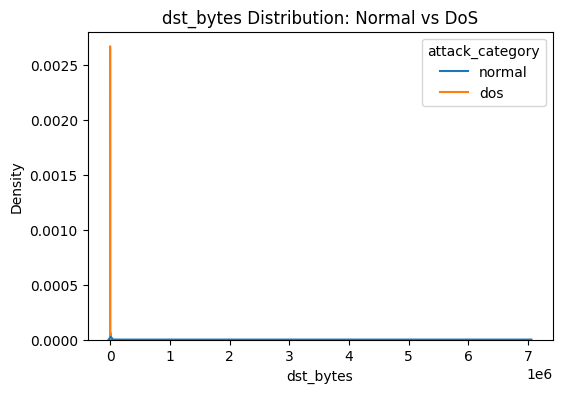

In [ ]:
# ===============================
# My Exploration — Feature Distribution: Normal vs DoS
# ===============================

features = ['duration','src_bytes','dst_bytes']

for f in features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=binary_train, x=f, hue='attack_category', common_norm=False)
    plt.title(f"{f} Distribution: Normal vs DoS")
    plt.show()

In [ ]:
#should check balance or to check proportion on normal vs DOS
binary_train['attack_category'].value_counts(normalize=True)
#so abot 56% normal and 44% DOS-not heavily imbalanced,so Random Forest or similar classifiers will work well


,proportion
attack_category,
normal,0.559569
dos,0.440431


In [ ]:
# Step 5: Aggregate / Roll-up by attack_category
agg_category = binary_train.groupby('attack_category')[['duration','src_bytes','dst_bytes']].mean()

print("\nAverage features per attack category:\n", agg_category)



Average features per attack category:
                   duration     src_bytes    dst_bytes
attack_category                                      
dos               0.006779   1216.122736   184.196051
normal           76.044813  16480.340672  5420.045802


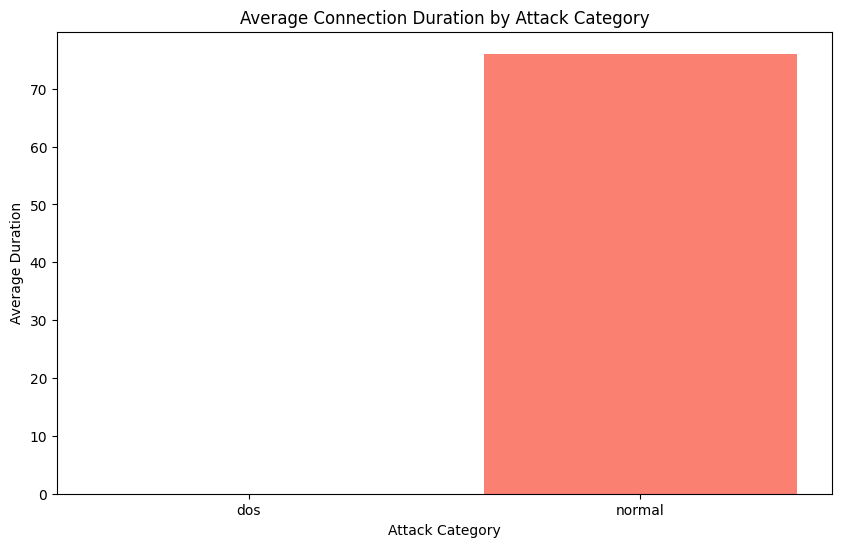

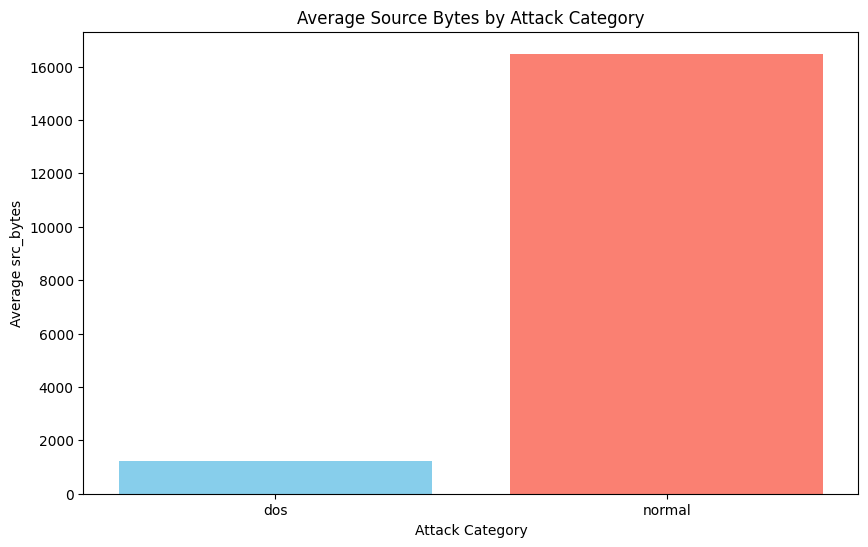

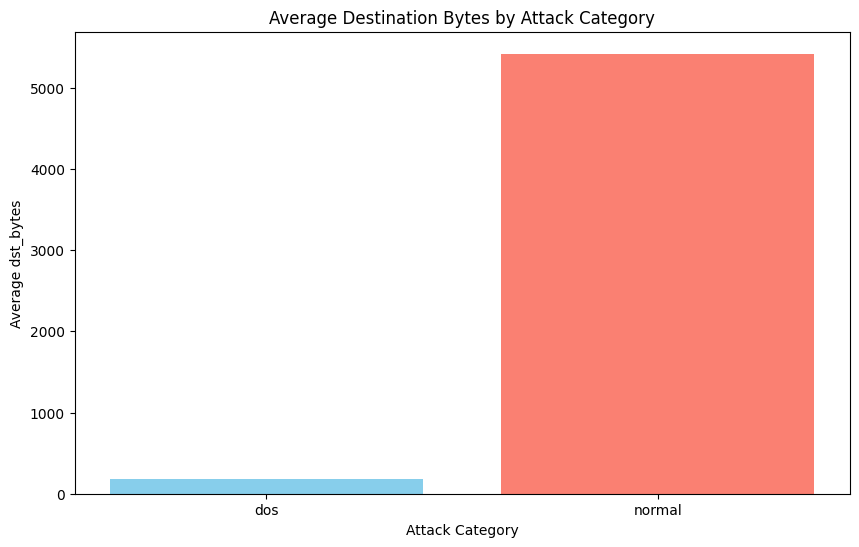

In [ ]:
#Bar plot of Average features by Attack Category
import matplotlib.pyplot as plt

# Aggregate average features per attack category
agg_category = binary_train.groupby('attack_category')[['duration','src_bytes','dst_bytes']].mean()
agg_category = agg_category.reset_index()

# Plot
plt.figure(figsize=(10,6))

# Plot duration
plt.bar(agg_category['attack_category'], agg_category['duration'], color=['skyblue','salmon'])
plt.title("Average Connection Duration by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average Duration")
plt.show()

# Plot src_bytes
plt.figure(figsize=(10,6))
plt.bar(agg_category['attack_category'], agg_category['src_bytes'], color=['skyblue','salmon'])
plt.title("Average Source Bytes by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average src_bytes")
plt.show()

# Plot dst_bytes
plt.figure(figsize=(10,6))
plt.bar(agg_category['attack_category'], agg_category['dst_bytes'], color=['skyblue','salmon'])
plt.title("Average Destination Bytes by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average dst_bytes")
plt.show()


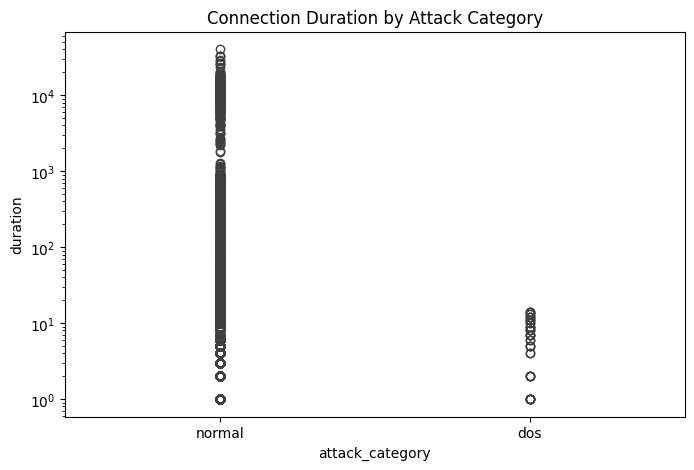

In [ ]:
# ===============================
# My Exploration — Duration by Attack Category
# ===============================

plt.figure(figsize=(8,5))
sns.boxplot(x=binary_train['attack_category'], y=binary_train['duration'])
plt.yscale('log')
plt.title("Connection Duration by Attack Category")
plt.show()

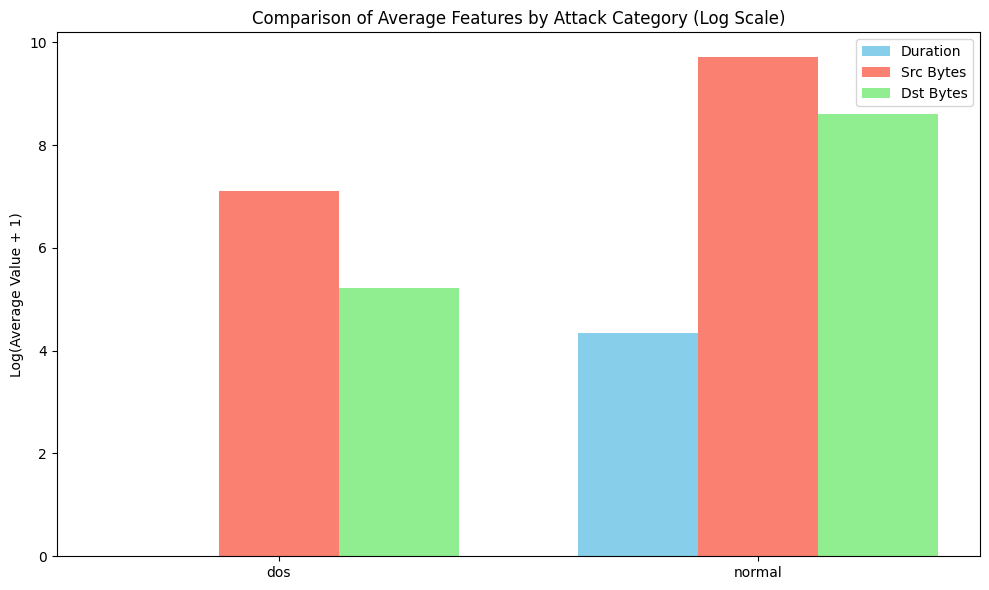

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Aggregate average features per attack category
agg_category = binary_train.groupby('attack_category')[['duration','src_bytes','dst_bytes']].mean()
agg_category = agg_category.reset_index()

# Apply log scale (log1p to handle zeros)
agg_category_log = agg_category.copy()
agg_category_log[['duration','src_bytes','dst_bytes']] = np.log1p(agg_category_log[['duration','src_bytes','dst_bytes']])

# Plot all three features in one grouped bar chart
features = ['duration','src_bytes','dst_bytes']
x = np.arange(len(agg_category_log['attack_category']))  # positions for attack categories
width = 0.25  # width of each bar

plt.figure(figsize=(10,6))

# Plot each feature
plt.bar(x - width, agg_category_log['duration'], width, label='Duration', color='skyblue')
plt.bar(x, agg_category_log['src_bytes'], width, label='Src Bytes', color='salmon')
plt.bar(x + width, agg_category_log['dst_bytes'], width, label='Dst Bytes', color='lightgreen')

# Labels and title
plt.xticks(x, agg_category_log['attack_category'])
plt.ylabel('Log(Average Value + 1)')
plt.title('Comparison of Average Features by Attack Category (Log Scale)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Columns to encode
categorical_cols = ['protocol_type', 'service', 'flag']

categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    # Combine train + test to ensure all labels are captured
    combined = pd.concat([binary_train[col], binary_test[col]], axis=0)
    codes, uniques = pd.factorize(combined)

    # Split back into train and test
    binary_train[col] = codes[:len(binary_train)]
    binary_test[col] = codes[len(binary_train):]


# Columns to normalize
numeric_cols = ['duration', 'src_bytes', 'dst_bytes']

# StandardScaler for numerical features
scaler = StandardScaler()
binary_train[numeric_cols] = scaler.fit_transform(binary_train[numeric_cols])
binary_test[numeric_cols] = scaler.transform(binary_test[numeric_cols])

# Save the processed datasets for reuse
binary_train.to_csv('derived_train_attack_category.csv', index=False)
binary_test.to_csv('derived_test_attack_category.csv', index=False)

print("Preprocessing completed. Derived datasets saved!")
print("Binary Train shape:", binary_train.shape)
print("Binary Test shape:", binary_test.shape)


/tmp/ipykernel_581/2515615440.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binary_train[col] = codes[:len(binary_train)]
/tmp/ipykernel_581/2515615440.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binary_test[col] = codes[len(binary_train):]
/tmp/ipykernel_581/2515615440.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

Preprocessing completed. Derived datasets saved!
Binary Train shape: (95788, 44)
Binary Test shape: (12865, 44)


Train shape: (95788, 44)
Test shape: (12865, 44)
Number of features: 41

Classification Report:

              precision    recall  f1-score   support

         dos       1.00      1.00      1.00      5023
      normal       1.00      1.00      1.00      7842

    accuracy                           1.00     12865
   macro avg       1.00      1.00      1.00     12865
weighted avg       1.00      1.00      1.00     12865



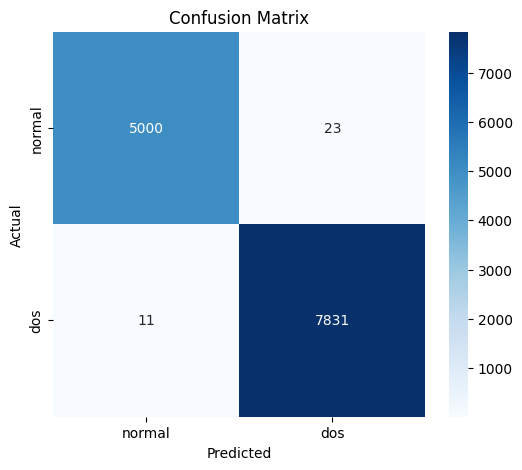

Number of misclassified samples: 34


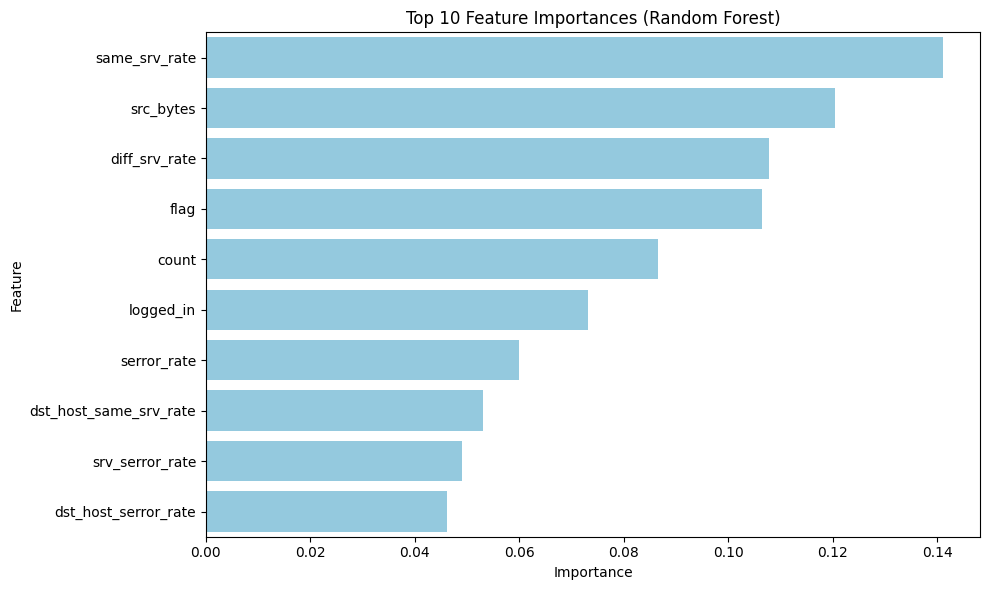

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load preprocessed datasets
train_df = pd.read_csv('derived_train_attack_category.csv')
test_df = pd.read_csv('derived_test_attack_category.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Step 2: Prepare features and target
X_train = train_df.drop(['attack_type','attack_category','level'], axis=1)
y_train = train_df['attack_category']

X_test = test_df.drop(['attack_type','attack_category','level'], axis=1)
y_test = test_df['attack_category']

print("Number of features:", X_train.shape[1])

# Step 3: Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate Model
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['normal','dos'], yticklabels=['normal','dos'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# My Exploration — Misclassified Samples
# ===============================

errors = X_test.copy()
errors['actual'] = y_test
errors['pred'] = y_pred

misclassified = errors[errors['actual'] != errors['pred']]

print("Number of misclassified samples:", len(misclassified))
misclassified.head()

# Step 6: Feature Importance

import pandas as pd

# Get importance values from model
importances = model.feature_importances_

# Create Series with feature names
feat_importances = pd.Series(importances, index=X_train.columns)

# Sort and select top 10
feat_importances = feat_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=feat_importances.values,
            y=feat_importances.index,
            color='skyblue')

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# ===============================
# My Interpretation — Important Features
# ===============================

important_features = feat_importances.index.tolist()

print("Most important features influencing attack detection:")
for f in important_features:
    print("-", f)

Most important features influencing attack detection:
- same_srv_rate
- src_bytes
- diff_srv_rate
- flag
- count
- logged_in
- serror_rate
- dst_host_same_srv_rate
- srv_serror_rate
- dst_host_serror_rate


In [ ]:
def categorize_attack(x):
    if x=='normal':
        return 'normal'
    elif x in['neptune','smurf','back','teardrop','pod','land']:
        return 'dos'
    elif x in ['satan','ipsweep','portsweep','nmap']:
        return 'probe' #scanning attacks
    elif x in ['guess_passwd','ftp_write','warezclient','warezmaster','phf','multihop','imap','spy','perl']:
        return 'r2l'  #Remote to Local
    elif x in ['buffer_overflow','loadmodule','rootkit']:
        return 'u2r' #User to Root
    else:
        return 'other'

train_df['attack_category'] = train_df['attack_type'].apply(categorize_attack)
test_df['attack_category'] = test_df['attack_type'].apply(categorize_attack)
print(train_df['attack_category'].value_counts())

attack_category
normal    53600
dos       42188
Name: count, dtype: int64


In [ ]:
#Definign feature Groups

categorical_features = ['protocol_type','service','flag']
binary_features = ['land','logged_in','is_host_login','is_guest_login']
#All the other numerical values

numerical_features = [col for col in columns if col not in categorical_features + binary_features +['label','difficulty_level']]

print(f"Categorical Features: {len(categorical_features)}")
print(f"Binary Features: {len(binary_features)}")
print(f"Numerical Features: {len(numerical_features)}")

print(train_df.isnull())

Categorical Features: 3
Binary Features: 4
Numerical Features: 36
       duration  protocol_type  service   flag  src_bytes  dst_bytes   land  \
0         False          False    False  False      False      False  False   
1         False          False    False  False      False      False  False   
2         False          False    False  False      False      False  False   
3         False          False    False  False      False      False  False   
4         False          False    False  False      False      False  False   
...         ...            ...      ...    ...        ...        ...    ...   
95783     False          False    False  False      False      False  False   
95784     False          False    False  False      False      False  False   
95785     False          False    False  False      False      False  False   
95786     False          False    False  False      False      False  False   
95787     False          False    False  False      False      Fa

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE, MutualInfoClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer

In [ ]:
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('ggplot')
sns.set_palette("husl")

# Define Column Names for NSL-KDD (Standard List)
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]

In [ ]:
train_path = './data/KDDTrain+.txt'
test_path = './data/KDDTest+.txt'

# Try loading with error handling for paths
try:
    df_train = pd.read_csv(train_path, header=None, names=COL_NAMES)
    df_test = pd.read_csv(test_path, header=None, names=COL_NAMES)
    print(f"Training Data Shape: {df_train.head()}")
    print(f"Test Data Shape: {df_test.tail()}")
except FileNotFoundError:
    print("Files not found. Please check the paths. Trying absolute paths or checking local directory...")
    # Fallback to local directory if paths are different
    if os.path.exists('KDDTrain+.txt'):
        df_train = pd.read_csv('KDDTrain+.txt', header=None, names=COL_NAMES)
        df_test = pd.read_csv('KDDTest+.txt', header=None, names=COL_NAMES)


Training Data Shape:    duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0

In [ ]:
categorical_features = ['protocol_type','service','flag']
binary_features = ['land','logged_in','is_host_login','is_guest_login']
#All the other numerical values

numerical_features = [col for col in COL_NAMES if col not in categorical_features + binary_features +['label','difficulty_level']]

print(f"Categorical Features: {len(categorical_features)}")
print(f"Binary Features: {len(binary_features)}")
print(f"Numerical Features: {len(numerical_features)}")

print(df_train.isnull())

Categorical Features: 3
Binary Features: 4
Numerical Features: 34
        duration  protocol_type  service   flag  src_bytes  dst_bytes   land  \
0          False          False    False  False      False      False  False   
1          False          False    False  False      False      False  False   
2          False          False    False  False      False      False  False   
3          False          False    False  False      False      False  False   
4          False          False    False  False      False      False  False   
...          ...            ...      ...    ...        ...        ...    ...   
125968     False          False    False  False      False      False  False   
125969     False          False    False  False      False      False  False   
125970     False          False    False  False      False      False  False   
125971     False          False    False  False      False      False  False   
125972     False          False    False  False      F

In [ ]:
def clean_outliers_isolation_forest(df,contamination = 0.01):
    iso_df  = df[numerical_features].copy()

    clf = IsolationForest(max_samples='auto',contamination = contamination, random_state = 42)

    outliers = clf.fit_predict(iso_df)

    n_outliers = (outliers == -1).sum()
    print(f"Identifies {n_outliers} Outlilers using the Isolation forest")

    return outliers
df_train['is_outlier'] = clean_outliers_isolation_forest(df_train)

Identifies 1256 Outlilers using the Isolation forest


In [ ]:
# Mapping Dictionary
attack_mapping = {
    'normal': 'normal',

    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',

    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',

    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L', 'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',

    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R', 'ps': 'U2R', 'xterm': 'U2R', 'sqlattack': 'U2R'
}

# Apply mapping
df_train['attack_class'] = df_train['label'].map(lambda x: attack_mapping.get(x, 'other'))
df_test['attack_class'] = df_test['label'].map(lambda x: attack_mapping.get(x, 'other'))

print("Training Class Distribution:")
print(df_train['attack_class'].value_counts())

Training Class Distribution:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


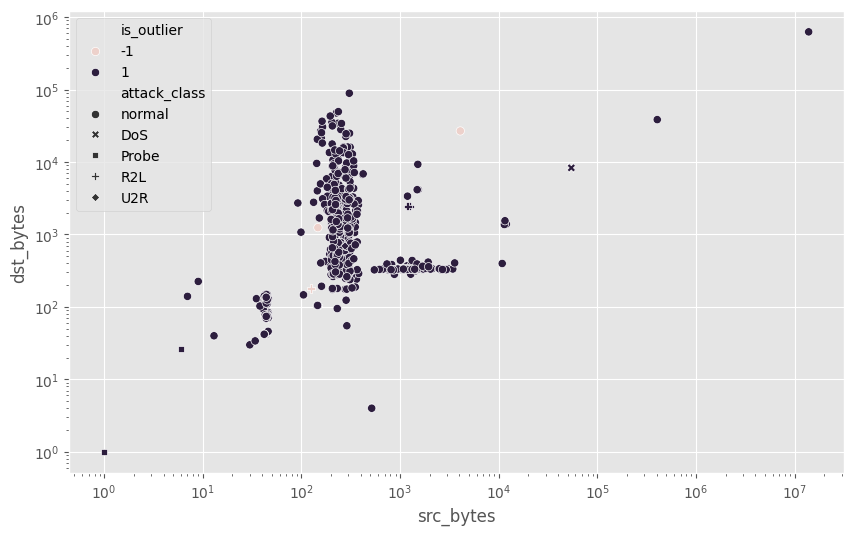

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_train[::100], x = 'src_bytes', y = 'dst_bytes', hue='is_outlier', style='attack_class')
plt.xscale('log')
plt.yscale('log')
plt.show()

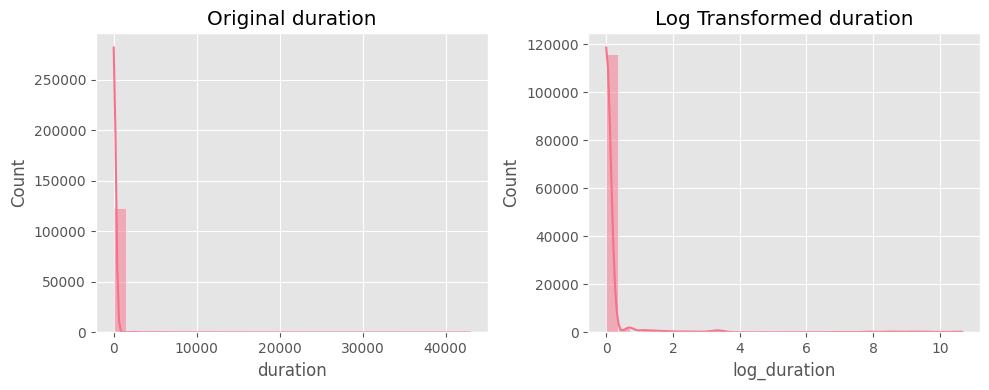

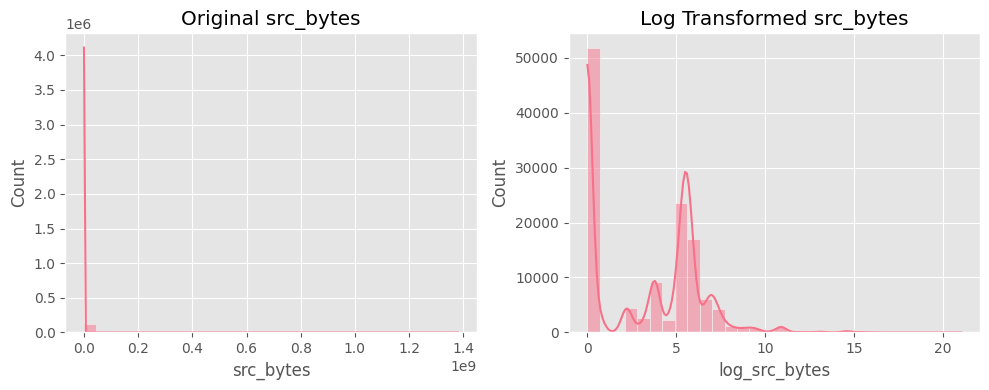

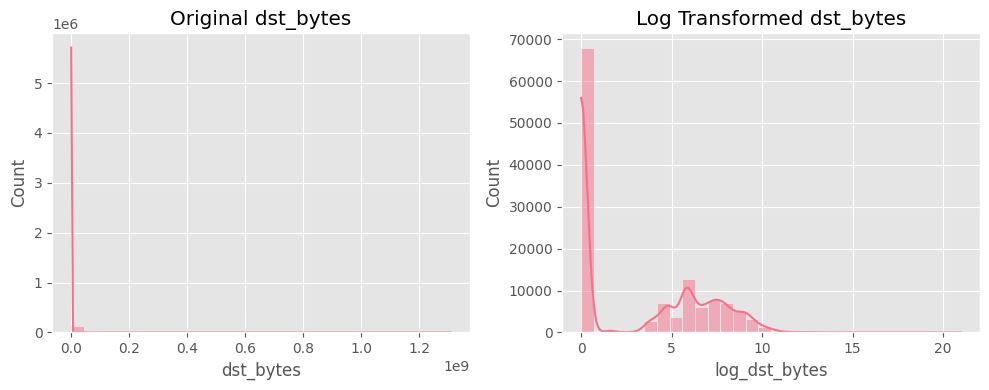

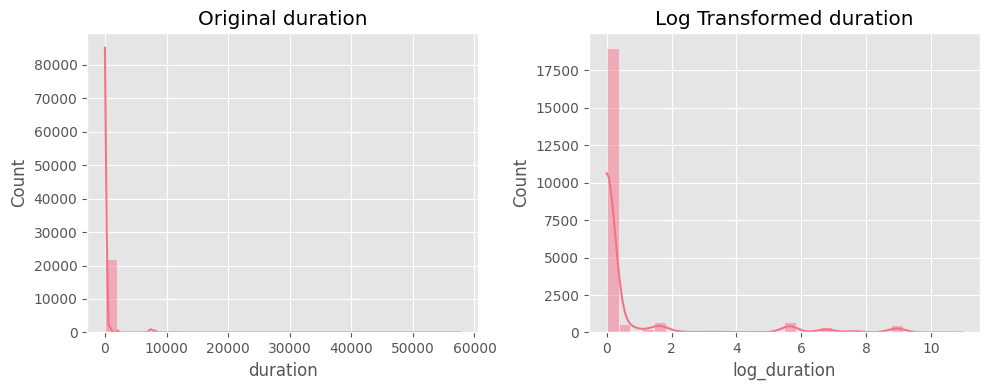

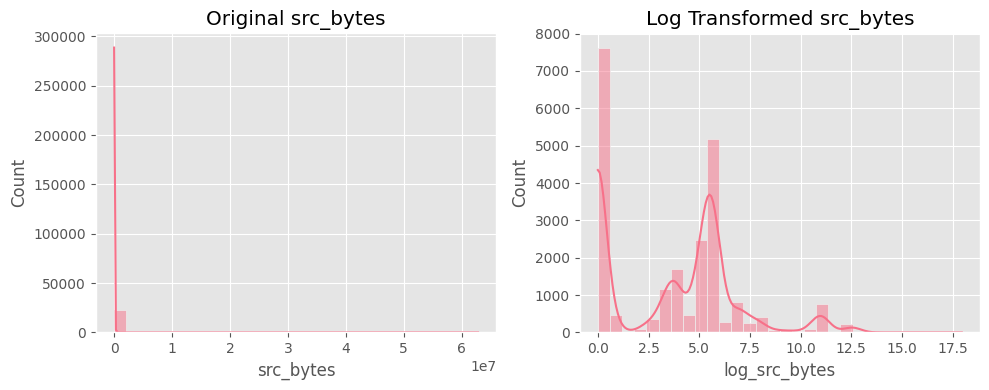

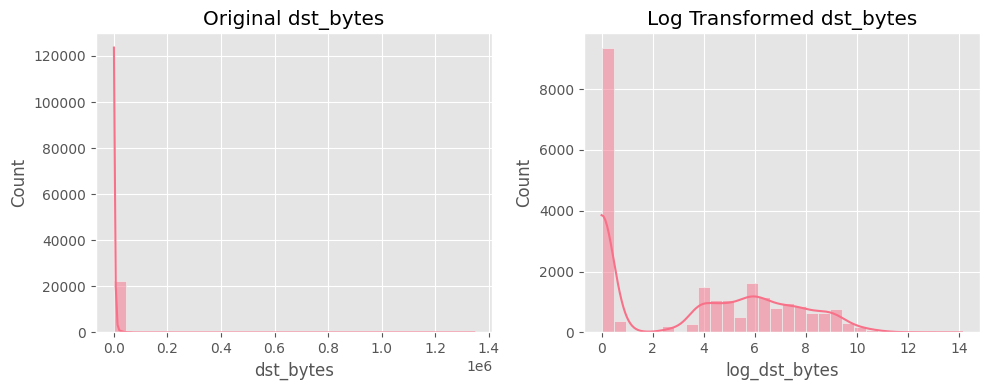

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

skewed_cols = ['duration','src_bytes','dst_bytes']

def apply_log_transform(df, cols):
    df_copy = df.copy()

    # Apply log1p to all selected columns at once
    df_copy[[f"log_{col}" for col in cols]] = np.log1p(df_copy[cols])

    # Plot comparison
    for col in cols:
        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Original {col}")

        plt.subplot(1,2,2)
        sns.histplot(df_copy[f"log_{col}"], bins=30, kde=True)
        plt.title(f"Log Transformed {col}")

        plt.tight_layout()
        plt.show()

    return df_copy


df_train = apply_log_transform(df_train, skewed_cols)
df_test = apply_log_transform(df_test, skewed_cols)

In [ ]:
def engineer_features(df):
    df_eng = df.copy()

    # 1. Total Bytes
    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']

    # 2. Byte Ratio (Handle division by zero)
    df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1e-5)

    # 3. Load / Packet Rate
    # If duration is 0, we assume it's a single instantaneous event (rate = count)
    df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1e-5)

    # 4. Title: Flow Asymmetry
    df_eng['byte_diff'] = abs(df_eng['src_bytes'] - df_eng['dst_bytes'])

    # 5. Flag interactions (example: is it an error flag?)
    error_flags = ['S0', 'S1', 'S2', 'S3', 'REJ']
    df_eng['is_error_flag'] = df_eng['flag'].isin(error_flags).astype(int)

    # 6. Critical Host Interaction
    # Interaction between 'same_srv_rate' and 'dst_host_same_srv_rate'
    df_eng['same_srv_interaction'] = df_eng['same_srv_rate'] * df_eng['dst_host_same_srv_rate']

    return df_eng

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("New Feature Set Head:")
print(df_train[['src_bytes_ratio', 'packet_rate', 'is_error_flag', 'same_srv_interaction']].head())

New Feature Set Head:
   src_bytes_ratio  packet_rate  is_error_flag  same_srv_interaction
0         1.000000     200000.0              0                 0.170
1         1.000000    1300000.0              0                 0.000
2         0.000000   12300000.0              1                 0.005
3         0.027668     500000.0              0                 1.000
4         0.321486    3000000.0              0                 1.000


In [ ]:
def engineer_features(df):
    return df.assign(
        total_bytes = df['src_bytes'] + df['dst_bytes'],
        src_bytes_ratio = df['src_bytes'] / (df['src_bytes'] + df['dst_bytes'] + 1e-5),
        packet_rate = df['count'] / (df['duration'] + 1e-5),
        byte_diff = abs(df['src_bytes'] - df['dst_bytes']),
        is_error_flag = df['flag'].isin(['S0','S1','S2','S3','REJ']).astype(int),
        same_srv_interaction = df['same_srv_rate'] * df['dst_host_same_srv_rate']
    )

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("New Feature Set Head:")
print(df_train[['src_bytes_ratio', 'packet_rate', 'is_error_flag', 'same_srv_interaction']].head())

New Feature Set Head:
   src_bytes_ratio  packet_rate  is_error_flag  same_srv_interaction
0         1.000000     200000.0              0                 0.170
1         1.000000    1300000.0              0                 0.000
2         0.000000   12300000.0              1                 0.005
3         0.027668     500000.0              0                 1.000
4         0.321486    3000000.0              0                 1.000


In [ ]:
df_train['service']

,service
0,ftp_data
1,other
2,private
3,http
4,http
...,...
125968,private
125969,private
125970,smtp
125971,klogin


In [ ]:
from sklearn.preprocessing import OneHotEncoder

cols_to_encode = ['protocol_type', 'flag']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on train
ohe.fit(df_train[cols_to_encode])

# Transform train & test directly
train_encoded = pd.DataFrame(
    ohe.transform(df_train[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_train.index
)

test_encoded = pd.DataFrame(
    ohe.transform(df_test[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_test.index
)

# Frequency encoding
freq_map = df_train['service'].value_counts(normalize=True)

df_train['service_freq'] = df_train['service'].map(freq_map)
df_test['service_freq'] = df_test['service'].map(freq_map).fillna(0)

# Final datasets
df_train_encode = pd.concat([df_train, train_encoded], axis=1)
df_test_encode = pd.concat([df_test, test_encoded], axis=1)
df_train_encode

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(df_train_encode.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'is_outlier',
       'attack_class', 'log_duration', 'log_src_bytes', 'log_dst_bytes',
       'total_bytes', 'src_bytes_ratio', 'packet_rate', 'byte_dif

In [ ]:
print(df_test_encode.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'log_duration', 'log_src_bytes', 'log_dst_bytes', 'total_bytes',
       'src_bytes_ratio', 'packet_rate', 'byte_diff', 'is_error_

In [ ]:
df_train_encode.drop(columns=['protocol_type','flag','service'],inplace = True)
df_test_encode.drop(columns=['protocol_type','flag','service'],inplace = True)

In [ ]:
print(df_train_encode.shape)

df_test_encode

(125973, 66)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,12983,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,20,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,0,15,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,794,333,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22540,0,317,938,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22541,0,54540,8314,0,0,0,2,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22542,0,42,42,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#to see col are numeric
df_numeric = df_train_encode.select_dtypes(include=['int64','float64'])

In [ ]:

print(df_numeric.shape)

(125973, 64)


In [ ]:
#to check data types
df_train_encode.dtypes

,0
duration,int64
src_bytes,int64
dst_bytes,int64
land,int64
wrong_fragment,int64
...,...
flag_S1,float64
flag_S2,float64
flag_S3,float64
flag_SF,float64


In [ ]:
df_numeric = df_train_encode.select_dtypes(include=np.number)

In [ ]:
import numpy as np

df_numeric = df_train_encode.select_dtypes(include=np.number)

print("Numeric features count:", df_numeric.shape[1])

Numeric features count: 64


In [ ]:
import numpy as np

corr_matrix = df_numeric.corr().abs()

In [ ]:
corr_matrix = df_numeric.corr()
corr_matrix

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
duration,1.000000,0.070737,0.034878,-0.001553,-0.009866,0.003830,0.000705,0.009528,-0.064218,0.042679,...,-0.034493,-0.005336,0.034268,0.539954,-0.068182,-0.005943,-0.003411,0.001148,-0.068255,-0.005119
src_bytes,0.070737,1.000000,0.000204,-0.000109,-0.000693,-0.000059,0.000295,-0.000208,-0.003353,-0.000086,...,-0.002429,0.007609,0.178046,-0.000685,-0.004800,0.000007,-0.000229,0.000682,-0.006079,-0.000360
dst_bytes,0.034878,0.000204,1.000000,-0.000069,-0.000440,0.000248,-0.000344,0.000504,-0.002894,0.001233,...,-0.001539,-0.000537,-0.000141,0.029685,-0.003042,0.000147,0.000215,-0.000077,-0.004509,-0.000228
land,-0.001553,-0.000109,-0.000069,1.000000,-0.001261,-0.000109,-0.001340,-0.000381,-0.011402,-0.000164,...,-0.004408,-0.001579,-0.000403,-0.001972,0.022781,-0.000759,-0.000448,-0.000278,-0.017074,-0.000654
wrong_fragment,-0.009866,-0.000693,-0.000440,-0.001261,1.000000,-0.000692,-0.008508,-0.002418,-0.072418,-0.001044,...,-0.027999,-0.010027,-0.002560,-0.012526,-0.055342,-0.004824,-0.002843,-0.001765,0.073840,-0.004155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
flag_S1,-0.005943,0.000007,0.000147,-0.000759,-0.004824,-0.000417,-0.000797,0.001808,0.052719,0.016717,...,-0.016867,-0.006040,-0.001542,-0.007546,-0.033338,1.000000,-0.001712,-0.001063,-0.065329,-0.002503
flag_S2,-0.003411,-0.000229,0.000215,-0.000448,-0.002843,-0.000246,0.008963,-0.000858,0.033628,-0.000360,...,-0.009940,-0.003560,-0.000909,-0.004447,-0.019646,-0.001712,1.000000,-0.000627,-0.038499,-0.001475
flag_S3,0.001148,0.000682,-0.000077,-0.000278,-0.001765,-0.000153,-0.000190,0.017265,0.019436,-0.000129,...,-0.006172,-0.002210,-0.000564,-0.002761,-0.012199,-0.001063,-0.000627,1.000000,-0.023906,-0.000916
flag_SF,-0.068255,-0.006079,-0.004509,-0.017074,0.073840,0.006383,0.074924,0.000136,0.641738,0.007291,...,-0.379191,-0.135793,-0.034668,-0.169644,-0.749485,-0.065329,-0.038499,-0.023906,1.000000,-0.056270


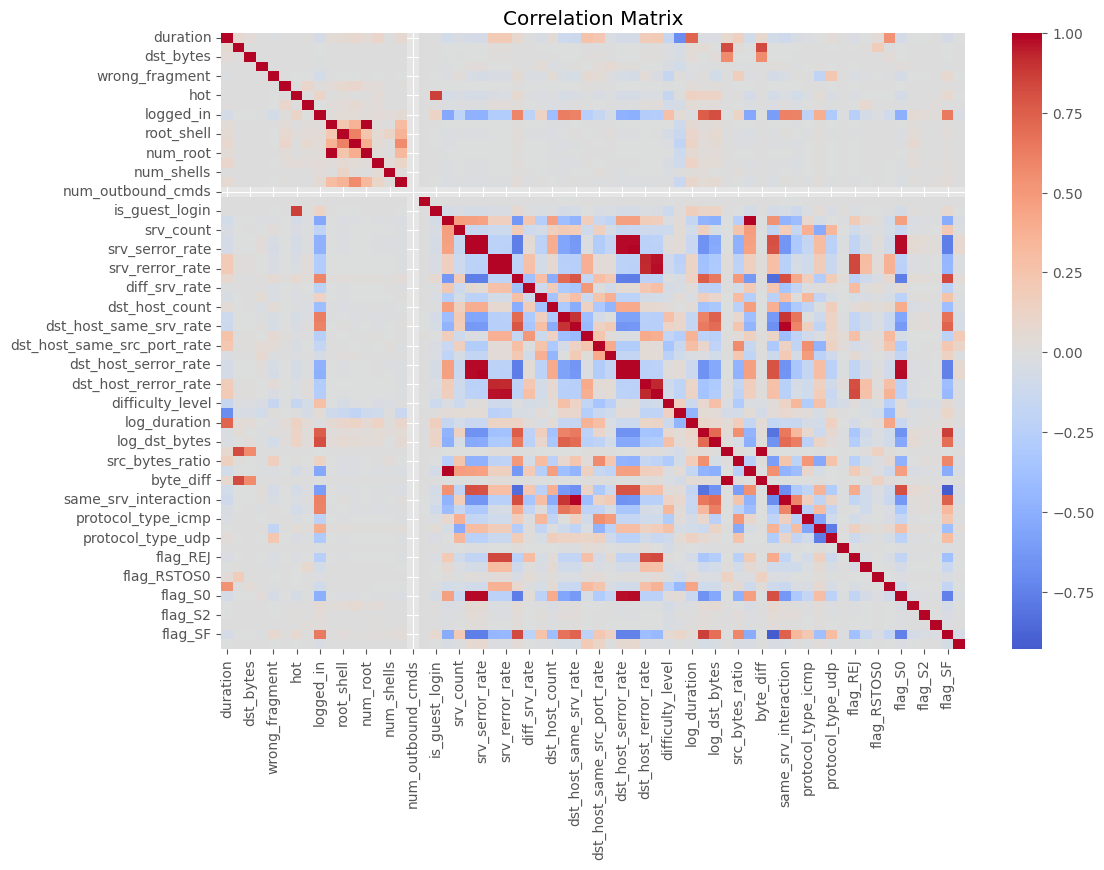

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns
df_numeric = df_train_encode.select_dtypes(include=np.number)

# Compute correlation
corr_matrix = df_numeric.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

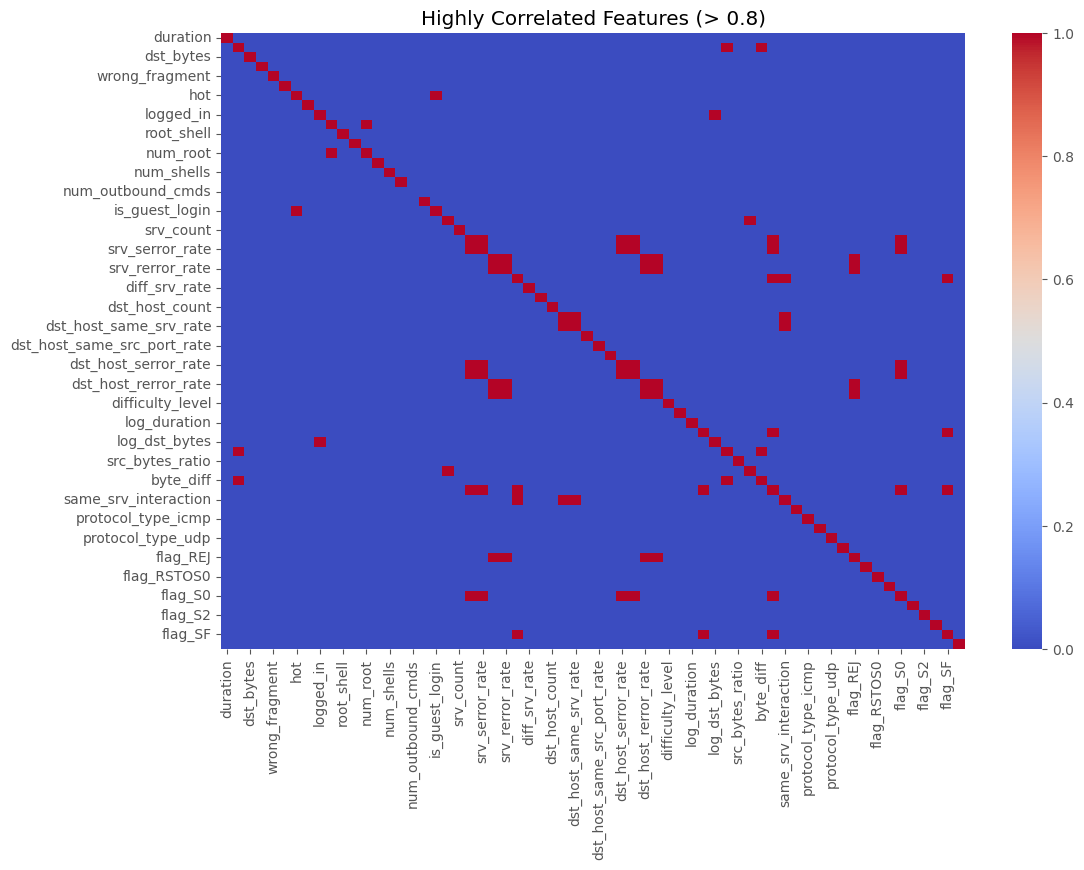

In [ ]:
#strong correlation
corr_matrix = df_numeric.corr().abs()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix > 0.8, cmap='coolwarm')
plt.title("Highly Correlated Features (> 0.8)")
plt.show()

In [ ]:
import numpy as np

df_numeric = df_train_encode.select_dtypes(include=np.number)

corr_matrix = df_numeric.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Highly correlated features:", to_drop_corr)

df_train_clean = df_numeric.drop(columns=to_drop_corr)
df_test_clean = df_test_encode.drop(columns=to_drop_corr)

Highly correlated features: ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0', 'flag_SF']


In [ ]:
# Ensure same columns before variance selection
#df_test_clean = df_test_clean.reindex(columns=df_train_clean.columns, fill_value=0)

#selector = VarianceThreshold(threshold=0.01)
#selector.fit(df_train_clean)

#selected_cols = df_train_clean.columns[selector.get_support()]

#df_train_clean = df_train_clean[selected_cols]
#df_test_clean = df_test_clean[selected_cols]

#print("Remaining features:", len(selected_cols))

In [ ]:
import numpy as np

df_numeric = df_train_encode.select_dtypes(include=np.number)

corr_matrix = df_numeric.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print("Highly correlated features:", to_drop_corr)

df_train_clean = df_numeric.drop(columns=to_drop_corr)
df_test_clean = df_test_encode.drop(columns=to_drop_corr)

Highly correlated features: ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0']


In [ ]:
# Ensure same columns before variance selection
#df_test_clean = df_test_clean.reindex(columns=df_train_clean.columns, fill_value=0)

#selector = VarianceThreshold(threshold=0.01)
#selector.fit(df_train_clean)

#selected_cols = df_train_clean.columns[selector.get_support()]

#df_train_clean = df_train_clean[selected_cols]
#df_test_clean = df_test_clean[selected_cols]

#print("Remaining features:", len(selected_cols))

In [ ]:
import numpy as np

df_numeric = df_train_encode.select_dtypes(include=np.number)

corr_matrix = df_numeric.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print("Highly correlated features:", to_drop_corr)

df_train_clean = df_numeric.drop(columns=to_drop_corr)
df_test_clean = df_test_encode.drop(columns=to_drop_corr)

Highly correlated features: ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0']


In [ ]:
from sklearn.preprocessing import RobustScaler

# Remove target + unwanted columns
cols_to_remove = ['label', 'attack_class', 'difficulty_level', 'is_outlier']

scale_features = [
    col for col in df_train_encode.columns
    if col not in cols_to_remove
]

# Apply RobustScaler
scaler = RobustScaler()

# Fit only on train
df_train_encode[scale_features] = scaler.fit_transform(
    df_train_encode[scale_features]
)

# Only transform test (NOT fit_transform)
df_test_encode[scale_features] = scaler.transform(
    df_test_encode[scale_features]
)

print(df_train_encode[scale_features[0:5]].describe())

           duration     src_bytes     dst_bytes           land  wrong_fragment
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   125973.000000
mean      287.14465  1.649375e+02  3.833162e+01       0.000198        0.022687
std      2604.51531  2.126932e+04  7.793157e+03       0.014086        0.253530
min         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
25%         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
50%         0.00000  0.000000e+00  0.000000e+00       0.000000        0.000000
75%         0.00000  8.405797e-01  1.000000e+00       0.000000        0.000000
max     42908.00000  4.999869e+06  2.538638e+06       1.000000        3.000000


In [ ]:
from sklearn.preprocessing import RobustScaler

# Remove target + unwanted columns
cols_to_remove = ['label', 'attack_class', 'difficulty_level', 'is_outlier']

scale_features = [
    col for col in df_train_encode.columns
    if col not in cols_to_remove
]

# Apply RobustScaler
scaler = RobustScaler()

# Fit only on train
df_train_encode[scale_features] = scaler.fit_transform(
    df_train_encode[scale_features]
)

# Only transform test (NOT fit_transform)
df_test_encode[scale_features] = scaler.transform(
    df_test_encode[scale_features]
)

print(df_train_encode[scale_features[0:5]].describe())

           duration     src_bytes     dst_bytes           land  wrong_fragment
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   125973.000000
mean      287.14465  1.649375e+02  3.833162e+01       0.000198        0.022687
std      2604.51531  2.126932e+04  7.793157e+03       0.014086        0.253530
min         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
25%         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
50%         0.00000  0.000000e+00  0.000000e+00       0.000000        0.000000
75%         0.00000  8.405797e-01  1.000000e+00       0.000000        0.000000
max     42908.00000  4.999869e+06  2.538638e+06       1.000000        3.000000


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd
# Define Features & Target
target_column = "attack_class"
feature_columns = [
    col for col in df_train_encode.columns
    if col not in ["label", "attack_class", "difficulty_level"]
]

X = df_train_encode[feature_columns].copy()
y = df_train_encode[target_column].copy()
#  Handle Missing Values
X = X.fillna(0)
# Check Class Distribution Before SMOTE
print("Class distribution BEFORE SMOTE:")
print(y.value_counts())
# Apply SMOTE
smote = SMOTE(
    sampling_strategy="auto",   # balances all minority classes
    k_neighbors=5,
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(X, y)
# Check Class Distribution After SMOTE
print("Class distribution AFTER SMOTE:")
print(pd.Series(y_resampled).value_counts())

Class distribution BEFORE SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64
Class distribution AFTER SMOTE:
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


In [ ]:
!pip install imbalanced-learn

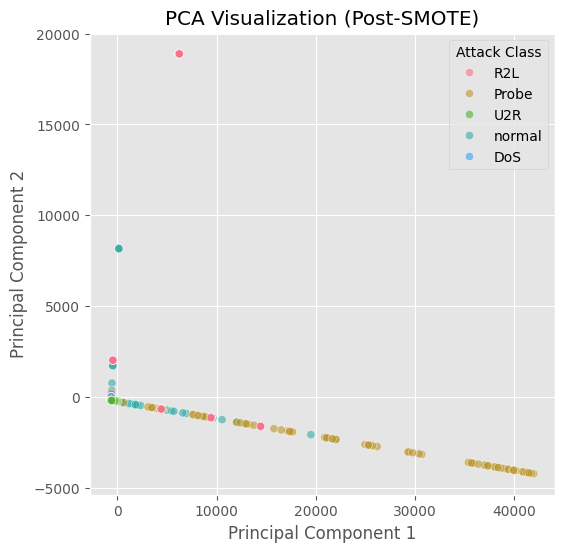

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
sample_idx = X_resampled.sample(5000, random_state=42).index
X_sample = X_resampled.loc[sample_idx] #just for understanding
y_sample = y_resampled.loc[sample_idx]
# Apply PCA
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(X_sample)
plt.figure(figsize=(6,6))
sns.scatterplot( x=x_pca[:,0], y=x_pca[:,1], hue=y_sample, alpha=0.6)
plt.title("PCA Visualization (Post-SMOTE)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Attack Class")
plt.show()

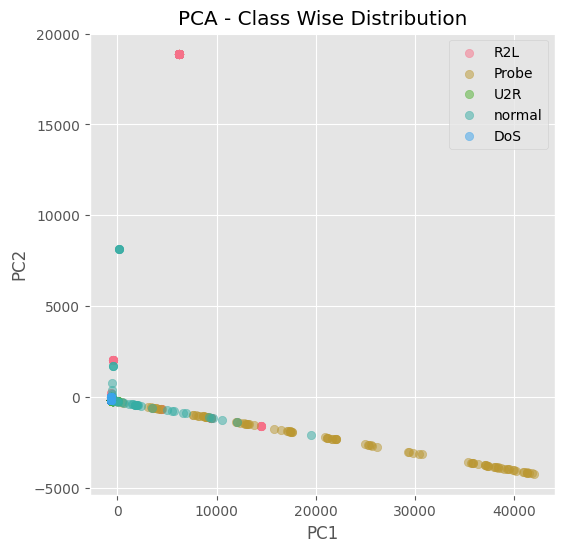

In [ ]:
#diff plots for clear understanding
plt.figure(figsize=(6,6))

for label in y_sample.unique():
    plt.scatter(
        x_pca[y_sample == label, 0],
        x_pca[y_sample == label, 1],
        label=label,
        alpha=0.5
    )

plt.title("PCA - Class Wise Distribution")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

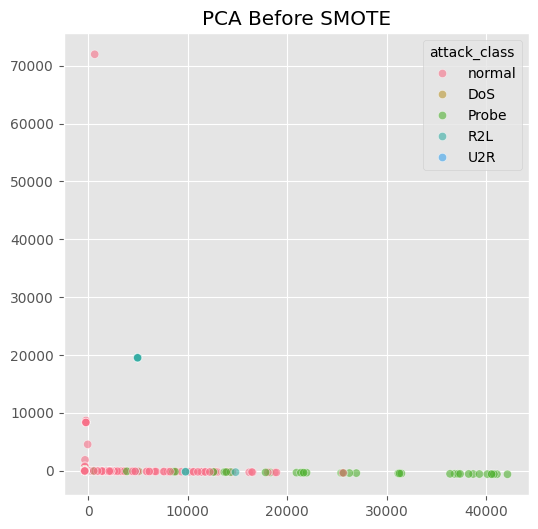

In [ ]:
# Before SMOTE
sample_idx_orig = X.sample(5000, random_state=42).index
X_orig_sample = X.loc[sample_idx_orig]
y_orig_sample = y.loc[sample_idx_orig]

pca_before = PCA(n_components=2, random_state=42)
x_pca_before = pca_before.fit_transform(X_orig_sample)

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=x_pca_before[:,0],
    y=x_pca_before[:,1],
    hue=y_orig_sample,
    alpha=0.6
)

plt.title("PCA Before SMOTE")
plt.show()


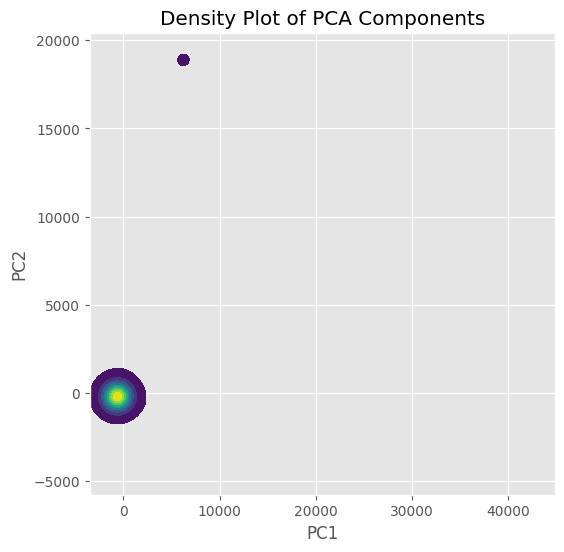

In [ ]:
plt.figure(figsize=(6,6))
sns.kdeplot(
    x=x_pca[:,0],
    y=x_pca[:,1],
    fill=True,
    cmap="viridis",
    thresh=0.05
)

plt.title("Density Plot of PCA Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
import os
output_dir = "../data/"
os.makedirs(output_dir, exist_ok=True)
# Combine TRAIN features + target
df_final_train = pd.concat([X_resampled, y_resampled], axis=1)
# Define save path
train_save_path = os.path.join(output_dir, "train_processed_advanced.csv")

# Save file
df_final_train.to_csv(train_save_path, index=False)

print(f"Saved the Train Data to {train_save_path}")

Saved the Train Data to ../data/train_processed_advanced.csv


In [ ]:
import os

output_dir = "../data/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [ ]:
import os
output_dir = "../data/"
os.makedirs(output_dir, exist_ok=True)
# Combine TRAIN features + target
df_final_test = pd.concat([X_resampled, y_resampled], axis=1)
# Define save path
test_save_path = os.path.join(output_dir, "test_processed_advanced.csv")

# Save file
df_final_test.to_csv(test_save_path, index=False)

print(f"Saved the Train Data to {test_save_path}")


Saved the Train Data to ../data/test_processed_advanced.csv


In [ ]:
print(df_final_train['attack_class'].value_counts())
print(df_final_train['attack_class'].value_counts(normalize=True))

attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64
attack_class
normal    0.2
DoS       0.2
R2L       0.2
Probe     0.2
U2R       0.2
Name: proportion, dtype: float64


In [ ]:
#actual samples for each class
print(y_resampled.value_counts())

attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
print(os.listdir())

['.config', 'data', 'derived_test_attack_category.csv', 'derived_train_attack_category.csv', 'sample_data']


In [ ]:
print(os.listdir("data"))

['KDDTrain+.txt', 'KDDTest+.txt']


In [ ]:
import os
print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
/content


In [ ]:
import pandas as pd
import os

print(os.listdir("data"))

df_train = pd.read_csv("../data/train_processed_advanced.csv")
df_test = pd.read_csv("../data/test_processed_advanced.csv")

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

['KDDTrain+.txt', 'KDDTest+.txt']
Train shape: (336715, 64)
Test shape: (336715, 64)


In [ ]:
#now we separate features and target
X_train = df_train.drop("attack_class", axis=1)
y_train = df_train["attack_class"]

X_test = df_test.drop("attack_class", axis=1)
y_test = df_test["attack_class"]

In [ ]:
#now we train KNN model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [ ]:
#now we will evaluate performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9966529557637764

Confusion Matrix:
 [[67314     3     1     1    24]
 [    0 67273     4     0    66]
 [    0     1 67261    10    71]
 [    0     0     0 67343     0]
 [   29   594   207   116 66397]]

Classification Report:
               precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     67343
       Probe       0.99      1.00      1.00     67343
         R2L       1.00      1.00      1.00     67343
         U2R       1.00      1.00      1.00     67343
      normal       1.00      0.99      0.99     67343

    accuracy                           1.00    336715
   macro avg       1.00      1.00      1.00    336715
weighted avg       1.00      1.00      1.00    336715



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# y_resampled is your target
le = LabelEncoder()
y_encoded = le.fit_transform(y_resampled)

print("Classes:", le.classes_)

Classes: ['DoS' 'Probe' 'R2L' 'U2R' 'normal']


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,        # number of trees
    random_state=42,         # reproducibility
    max_depth=10,            # lightweight model
    n_jobs=-1                # use all CPU cores
)

rf.fit(X_resampled, y_encoded)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X_resampled.columns)

# Sort descending
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(20))

src_bytes                      0.059161
total_bytes                    0.057999
service_freq                   0.056615
dst_host_srv_count             0.054806
logged_in                      0.048064
byte_diff                      0.047441
log_src_bytes                  0.045422
dst_bytes                      0.044810
root_shell                     0.037875
log_dst_bytes                  0.037790
dst_host_same_src_port_rate    0.033032
srv_count                      0.032618
src_bytes_ratio                0.030553
dst_host_diff_srv_rate         0.030076
dst_host_serror_rate           0.029559
flag_S0                        0.028412
num_file_creations             0.027580
count                          0.024759
packet_rate                    0.024105
serror_rate                    0.022919
dtype: float64


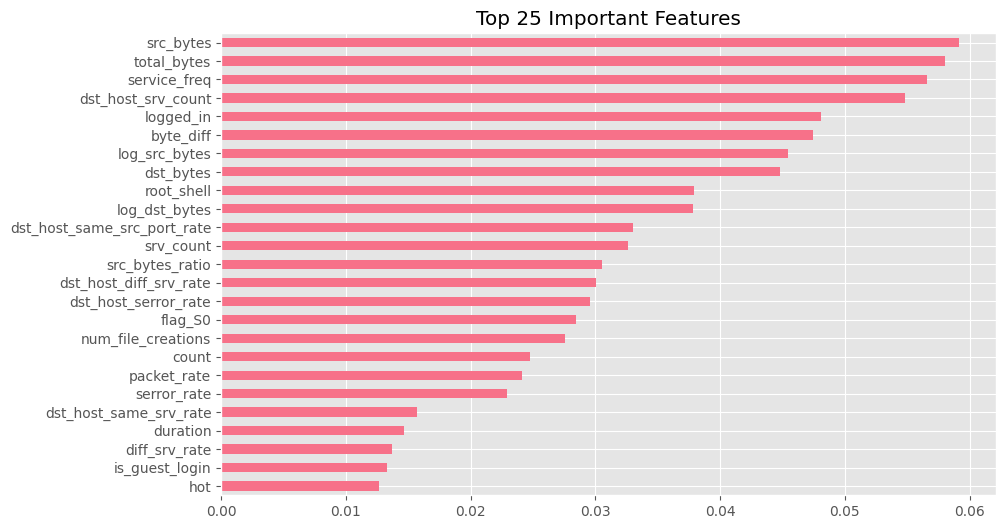

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(25)

plt.figure(figsize=(10,6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 25 Important Features")
plt.show()

In [ ]:
threshold = 0.001

low_importance_features = feature_importance[feature_importance < threshold]

print("Number of low importance features:", len(low_importance_features))
print(low_importance_features)

Number of low importance features: 16
flag_RSTR            0.000915
flag_SH              0.000660
flag_REJ             0.000630
is_outlier           0.000428
num_access_files     0.000389
num_shells           0.000217
urgent               0.000094
flag_S1              0.000065
su_attempted         0.000065
flag_S3              0.000029
flag_RSTOS0          0.000021
land                 0.000008
flag_S2              0.000005
flag_OTH             0.000001
is_host_login        0.000000
num_outbound_cmds    0.000000
dtype: float64


In [ ]:
X_selected = X_resampled.drop(columns=low_importance_features.index)

print("New shape after feature selection:", X_selected.shape)

New shape after feature selection: (336715, 47)
